<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Feature%20Selection%20and%20Engineering/Feature_Selection_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import requests
import io

# Construct the raw URL for the data.csv file
url = "https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Feature%20Selection%20and%20Engineering/FeatureSelection.csv"

print(f'Attempting to fetch data from: {url}')

try:
    # Use requests to get the content of the raw CSV file
    response = requests.get(url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    # Read the content into a pandas DataFrame using io.StringIO
    custom_df = pd.read_csv(io.StringIO(response.text))

    # Display the first 5 rows of the DataFrame
    print('Dataset loaded successfully:')
    display(custom_df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching data: {e}")
    print("Please verify the URL and your internet connection.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Attempting to fetch data from: https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Feature%20Selection%20and%20Engineering/FeatureSelection.csv
Dataset loaded successfully:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,0.304717,0.337575,0.134397,0.515410,0.0,0.048817,1.0,-0.845045,-0.059283,-1.322541,1
1,-1.039984,1.407482,-0.500314,-0.577539,0.0,1.915544,0.0,-1.083699,-0.729287,-0.486194,0
2,0.750451,0.090585,0.457278,1.274447,0.0,-0.021409,0.0,0.344605,-0.414473,0.420227,1
3,0.940565,0.643939,0.430908,-0.627588,0.0,0.301963,0.0,0.379280,0.633910,-0.102397,1
4,-1.951035,-2.050172,-0.923401,-0.636615,0.0,4.114603,0.0,1.287331,0.002993,-0.650564,0


### Data understanding: Scatterplot Matrix

The scatterplot matrix visualize the relationships between couple of features and the target variable.  This can help identify feature-to-feature relationships.

<Figure size 1000x800 with 0 Axes>

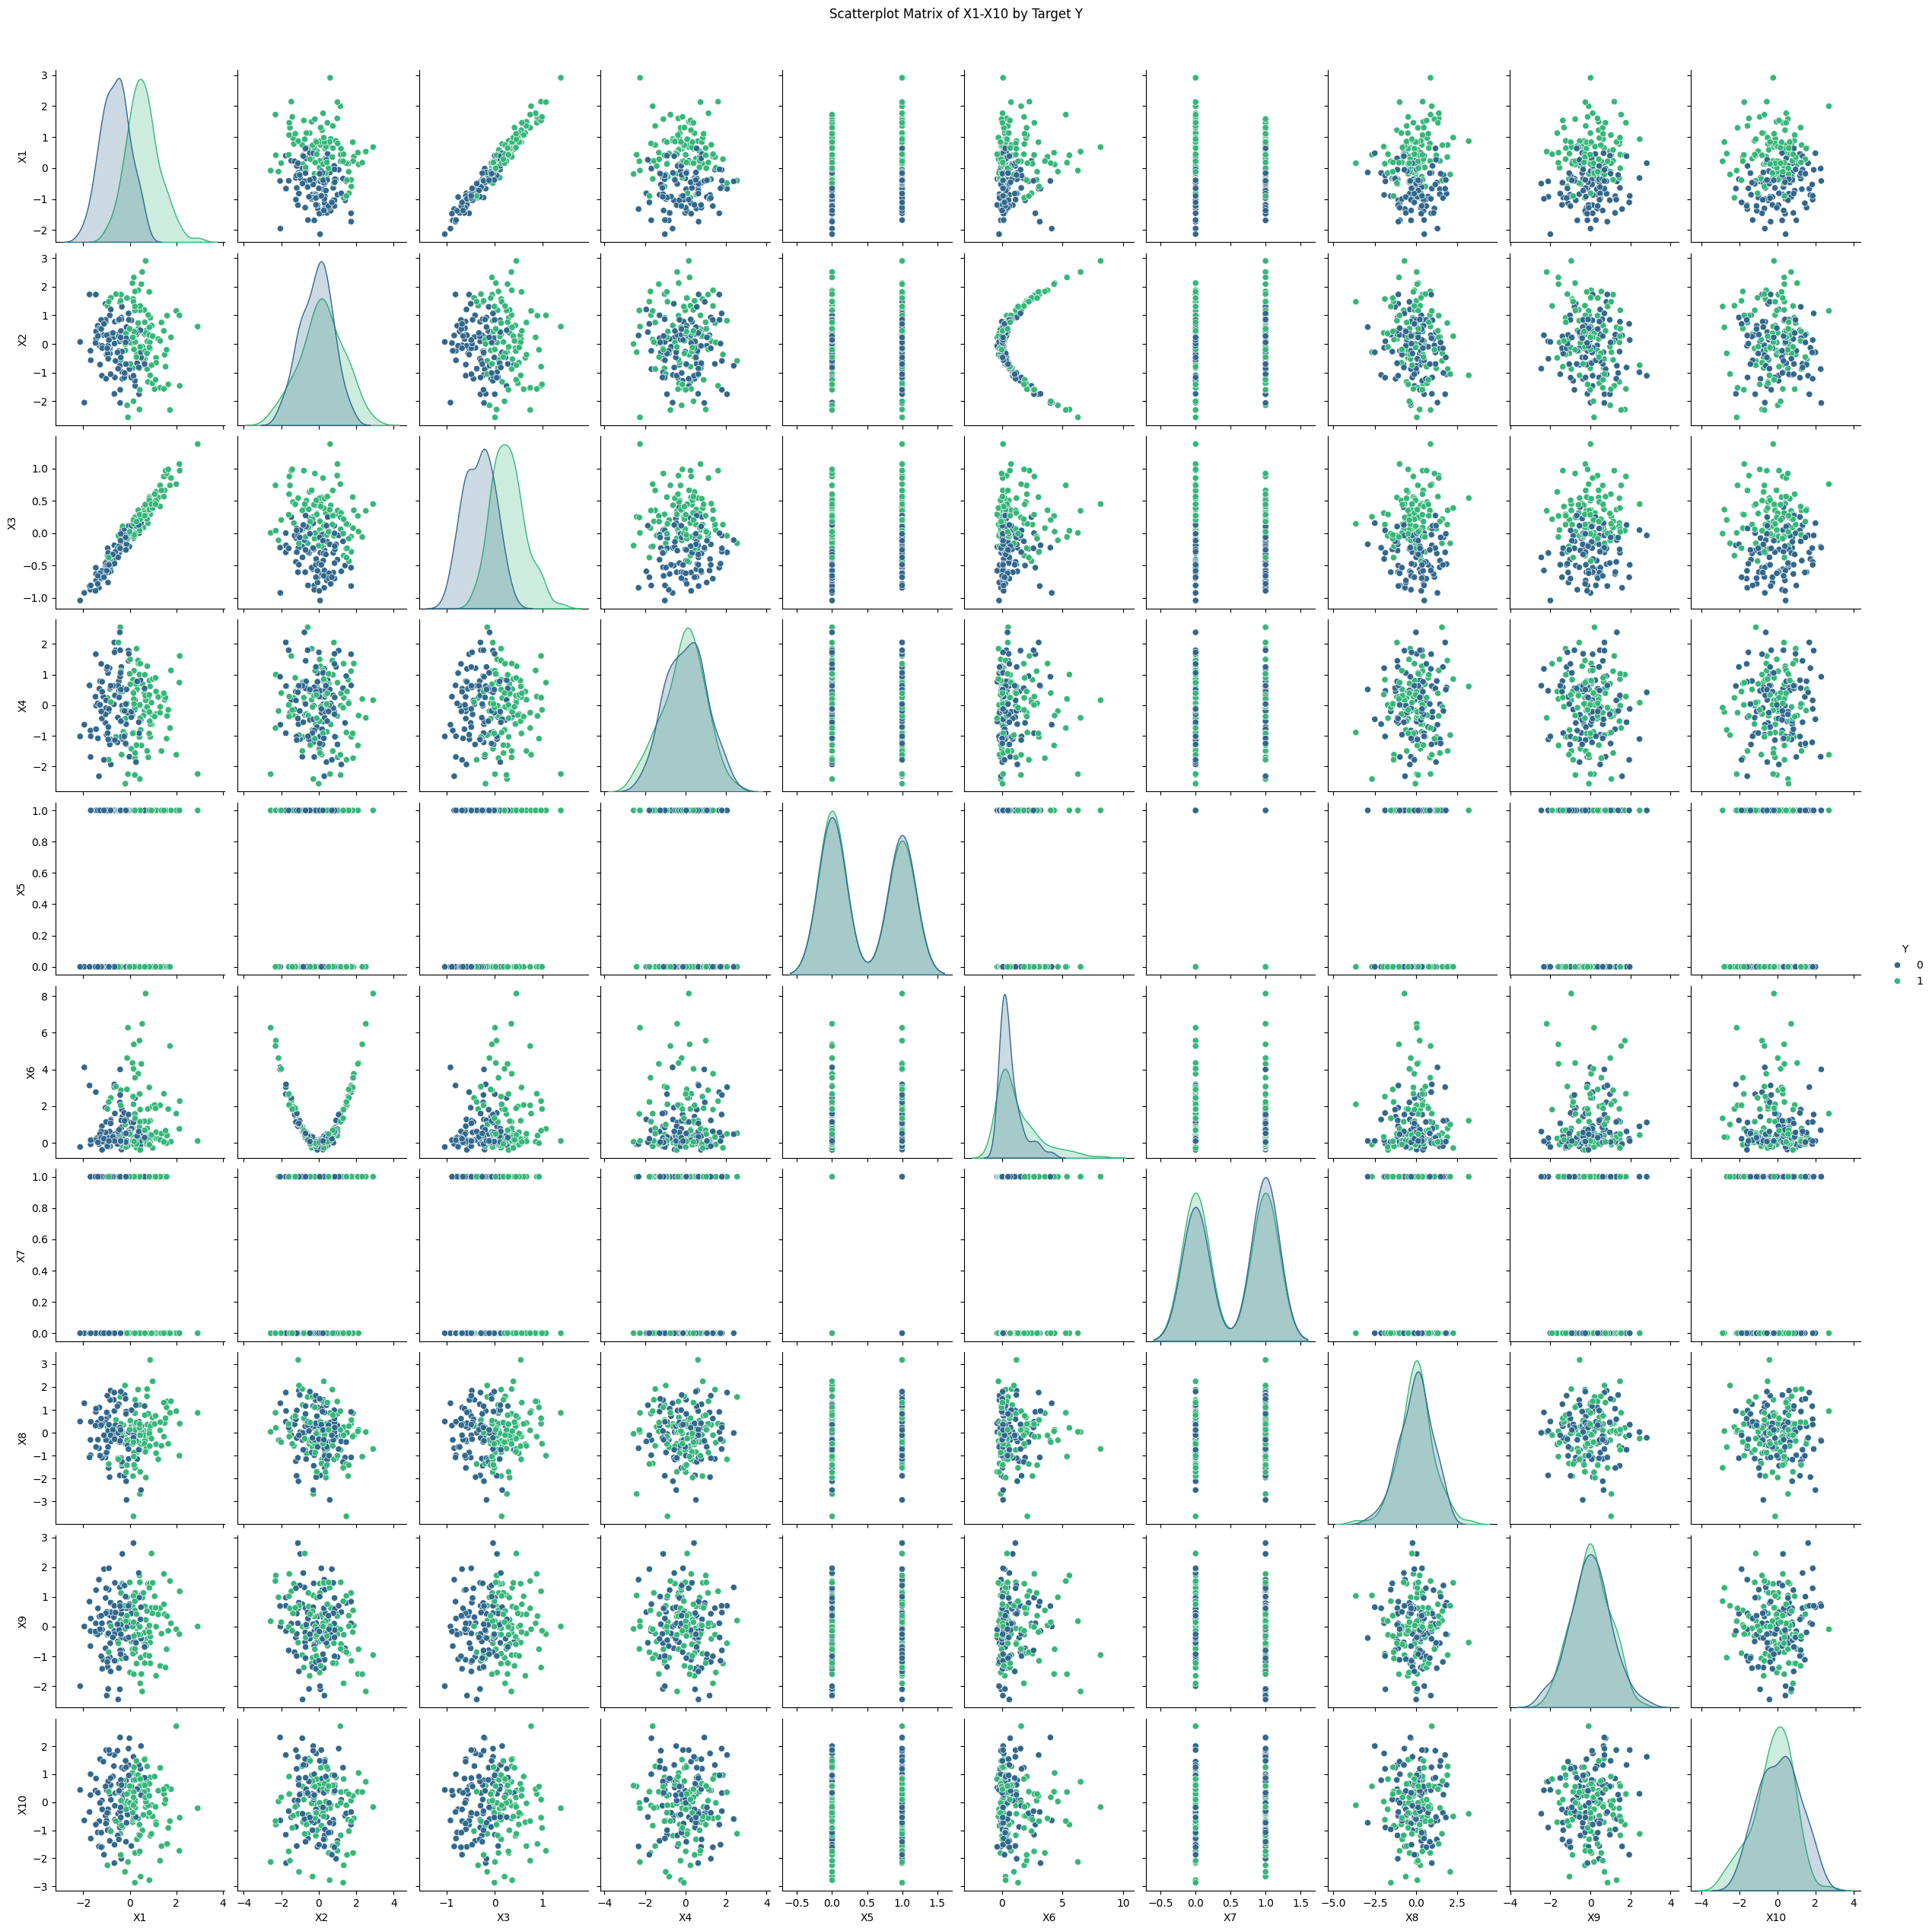

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot 1: Features X1 to X7 and Y
plt.figure(figsize=(10, 8))
sns.pairplot(custom_df, vars=['X1', 'X2', 'X3','X4','X5', 'X6', 'X7', 'X8', 'X9', 'X10'], hue='Y', palette='viridis', diag_kind='kde')
plt.suptitle('Scatterplot Matrix of X1-X10 by Target Y', y=1.02) # Adjust suptitle position
plt.show()

### Data understanding: Box Plots for Each Feature by Target Class

These box plots visualize the distribution of each feature (`X1` to `X10`) across the different classes of the target variable `Y`. This can help identify features that show clear separation between classes, indicating their predictive power.

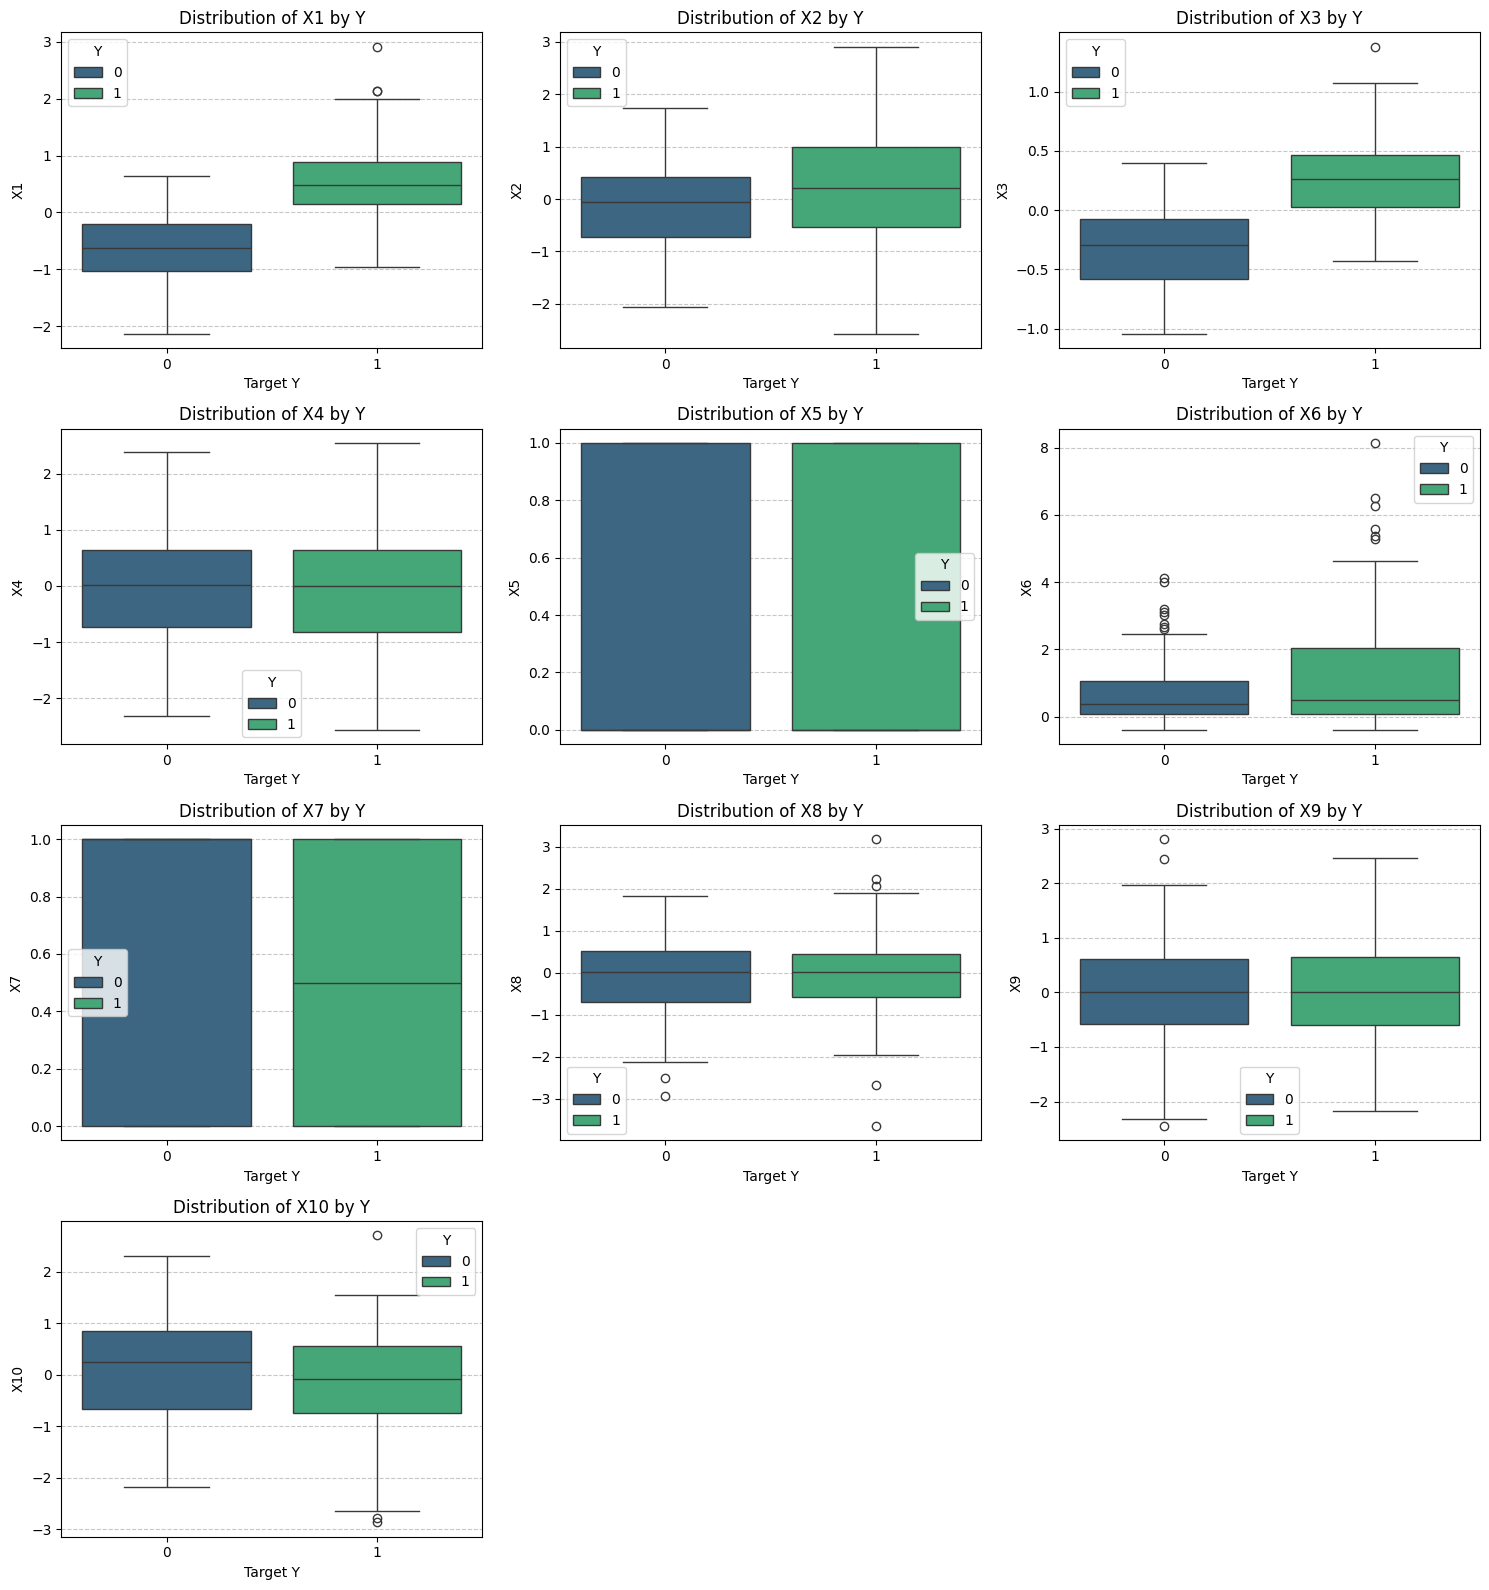

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names (excluding the target 'Y')
feature_columns = custom_df.drop('Y', axis=1).columns

# Determine number of rows and columns for the subplot grid
n_features = len(feature_columns)
n_cols = 3  # For example, 3 columns per row
n_rows = (n_features + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4)) # Adjust figure size dynamically

for i, feature in enumerate(feature_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x='Y', y=feature, data=custom_df, palette='viridis', hue='Y') # Added hue='Y'
    plt.title(f'Distribution of {feature} by Y')
    plt.xlabel('Target Y')
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Baseline Classifier
We will initially normalize data and split train and test set.
Then we run two baseline classifiers without carrying out feature selection:
*   KNN will use a 10-feature euclidean distance function
*   Decision tree embeds a feature selection approach



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd
import numpy as np

# --- Data Preparation (Normalization and Train/Test Split) ---
# Separate features (X) and target (Y)
X = custom_df.drop('Y', axis=1).values
Y = custom_df['Y'].values

print("--- Data Preparation ---")
# 1) Normalize the features with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features normalized successfully.")

# 2) Split training set and test set
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.3, random_state=42, stratify=Y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# --- Baseline Model: K-Nearest Neighbors (K-NN) ---
print("\n--- Baseline Model: K-Nearest Neighbors (K-NN) ---")
# 3) Train a K-NN on the training set and test its performance on the test set
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common default
knn_model.fit(X_train, Y_train)

Y_pred_knn = knn_model.predict(X_test)

print(f"Accuracy: {accuracy_score(Y_test, Y_pred_knn):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_knn, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_knn))

# --- Baseline Model: Decision Tree ---
print("\n--- Baseline Model: Decision Tree ---")
# 4) Train a Decision Tree on the training set and test its performance on the test set
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)

Y_pred_dt = dt_model.predict(X_test)

print(f"Accuracy: {accuracy_score(Y_test, Y_pred_dt):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_dt, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_dt))

# Feature importance for Decision Tree
feature_names = custom_df.drop('Y', axis=1).columns.tolist()
feature_importances_dt = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nDecision Tree Feature Importances:")
display(feature_importances_dt)



--- Data Preparation ---
Features normalized successfully.
Training set shape: (140, 10)
Testing set shape: (60, 10)

--- Baseline Model: K-Nearest Neighbors (K-NN) ---
Accuracy: 0.8500
F1-Score (weighted): 0.8496
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        30
           1       0.89      0.80      0.84        30

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60


--- Baseline Model: Decision Tree ---
Accuracy: 0.8333
F1-Score (weighted): 0.8333
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        30
           1       0.83      0.83      0.83        30

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60


D

,Feature,Importance
2,X3,0.478932
1,X2,0.151981
9,X10,0.080450
3,X4,0.079669
5,X6,0.069841
7,X8,0.061837
0,X1,0.049237
4,X5,0.028052
6,X7,0.000000
8,X9,0.000000


### Feature Selection Method 1: Mutual Information (Univariate Filter)

Mutual Information measures the dependency between two variables. For feature selection, `mutual_info_classif` estimates mutual information between each feature and the target variable. We will select the top features based on their scores.

In [ ]:
# --- Feature Selection Method 1: Mutual Information (Univariate Filter) ---
print("\n--- Applying Mutual Information Feature Selection ---")

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_train, Y_train, random_state=42)

# Create a DataFrame to display scores
mi_df = pd.DataFrame({
    'Feature': feature_names,
    'Mutual Information Score': mi_scores
}).sort_values(by='Mutual Information Score', ascending=False)

display(mi_df)

# Select the top 4 features based on Mutual Information (as an example)
k_features_mi = 4
selector_mi = SelectKBest(mutual_info_classif, k=k_features_mi)
selector_mi.fit(X_train, Y_train)

X_train_mi_selected = selector_mi.transform(X_train)
X_test_mi_selected = selector_mi.transform(X_test)

# Get the names of the selected features
selected_features_mi = [feature_names[i] for i in selector_mi.get_support(indices=True)]
print(f"\nSelected Features by Mutual Information (top {k_features_mi}): {selected_features_mi}")

print("\n--- Training K-NN on Mutual Information Selected Features ---")
# Train K-NN on the selected features
knn_mi = KNeighborsClassifier(n_neighbors=5)
knn_mi.fit(X_train_mi_selected, Y_train)

Y_pred_mi = knn_mi.predict(X_test_mi_selected)

print("\n--- K-NN Performance with Mutual Information Selected Features ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_mi):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_mi, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_mi))


--- Applying Mutual Information Feature Selection ---


,Feature,Mutual Information Score
2,X3,0.291529
0,X1,0.266812
4,X5,0.107828
9,X10,0.057860
3,X4,0.033710
8,X9,0.008613
1,X2,0.001714
5,X6,0.000000
7,X8,0.000000
6,X7,0.000000



Selected Features by Mutual Information (top 4): ['X1', 'X3', 'X4', 'X10']

--- Training K-NN on Mutual Information Selected Features ---

--- K-NN Performance with Mutual Information Selected Features ---
Accuracy: 0.8500
F1-Score (weighted): 0.8490
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84        30
           1       0.80      0.93      0.86        30

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60



### Feature Selection Method 3: Wrapper Method - K-NN with Sequential Forward Selection (SFS)

Sequential Forward Selection (SFS) is a greedy algorithm that iteratively adds the best performing feature to the selected subset. We will use a K-NN classifier as the estimator for evaluating feature subsets.

In [ ]:
import numpy as np
import pandas as pd

# Uncomment and run the following line if mlxtend is not installed
#!pip install mlxtend

from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("\n--- Applying Sequential Forward Selection (SFS) with K-NN ---")

# Initialize the K-NN classifier (estimator for SFS)
knn_sfs = KNeighborsClassifier(n_neighbors=5)

# Initialize SFS
# Set k_features='best' to automatically select the number of features that yield the highest score.
sfs1 = SFS(knn_sfs,
           k_features=4,
           #k_features='best',
           forward=True, # Forward selection
           floating=False,
           verbose=0, # Set to 2 for more verbose output
           scoring='f1_weighted', # Use weighted F1-score for evaluation
           cv=3, # 3-fold cross-validation
           n_jobs=-1) # Use all available cores

# Fit SFS to the training data
sfs1 = sfs1.fit(X_train, Y_train)

# Get the selected features
selected_features_sfs = [feature_names[i] for i in sfs1.k_feature_idx_]
print(f"\nSelected Features by SFS (top {len(sfs1.k_feature_idx_)}): {selected_features_sfs}")

# Transform the training and test sets with the selected features
X_train_sfs_selected = sfs1.transform(X_train)
X_test_sfs_selected = sfs1.transform(X_test)

print("\n--- Training K-NN on SFS Selected Features ---")
# Train K-NN on the SFS selected features
knn_sfs_model = KNeighborsClassifier(n_neighbors=5)
knn_sfs_model.fit(X_train_sfs_selected, Y_train)

Y_pred_sfs = knn_sfs_model.predict(X_test_sfs_selected)

print("\n--- K-NN Performance with SFS Selected Features ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_sfs):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_sfs, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_sfs))

# Display the SFS results (feature performance)
print("\nSFS Feature Selection Results (f1_weighted):")
sfs_results_df = pd.DataFrame.from_dict(sfs1.get_metric_dict()).T
display(sfs_results_df.sort_values(by='avg_score', ascending=False))


--- Applying Sequential Forward Selection (SFS) with K-NN ---

Selected Features by SFS (top 4): ['X1', 'X2', 'X3', 'X8']

--- Training K-NN on SFS Selected Features ---

--- K-NN Performance with SFS Selected Features ---
Accuracy: 0.8667
F1-Score (weighted): 0.8653
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85        30
           1       0.81      0.97      0.88        30

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60


SFS Feature Selection Results (f1_weighted):


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
2,"(0, 1)","[0.7653205963236359, 0.8048095093556317, 0.868...",0.812901,"(0, 1)",0.095726,0.042538,0.030079
3,"(0, 1, 2)","[0.7638229957990122, 0.7817178881008668, 0.824...",0.790101,"(0, 1, 2)",0.057551,0.025575,0.018084
4,"(0, 1, 2, 7)","[0.7444495837187789, 0.7782354823228284, 0.826...",0.782924,"(0, 1, 2, 7)",0.07537,0.033493,0.023683
1,"(0,)","[0.7432882011605416, 0.7411737198971241, 0.846...",0.776823,"(0,)",0.110104,0.048928,0.034597


### Feature Selection Method 4: Wrapper Method - K-NN with Sequential Backward Elimination (SBE)

Sequential Backward Elimination (SBE) is a greedy algorithm that starts with the full set of features and iteratively removes the worst performing feature based on a chosen metric, until the desired number of features is reached. We will again use a K-NN classifier as the estimator.

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

print("\n--- Applying Sequential Backward Elimination (SBE) with K-NN ---")

# Initialize the K-NN classifier (estimator for SBE)
knn_sbe = KNeighborsClassifier(n_neighbors=5)

# Initialize SBE
# We'll select 4 features for consistency, and use f1_weighted as scoring
sbs1 = SFS(knn_sbe,
           #k_features=4,
           k_features='best',
           forward=False, # Backward selection
           floating=False,
           verbose=0,
           scoring='f1_weighted',
           cv=3,
           n_jobs=-1)

# Fit SBE to the training data
sbs1 = sbs1.fit(X_train, Y_train)

# Get the selected features
selected_features_sbe = [feature_names[i] for i in sbs1.k_feature_idx_]
print(f"\nSelected Features by SBE (top {len(sbs1.k_feature_idx_)}): {selected_features_sbe}")

# Transform the training and test sets with the selected features
X_train_sbe_selected = sbs1.transform(X_train)
X_test_sbe_selected = sbs1.transform(X_test)

print("\n--- Training K-NN on SBE Selected Features ---")
# Train K-NN on the SBE selected features
knn_sbe_model = KNeighborsClassifier(n_neighbors=5)
knn_sbe_model.fit(X_train_sbe_selected, Y_train)

Y_pred_sbe = knn_sbe_model.predict(X_test_sbe_selected)

print("\n--- K-NN Performance with SBE Selected Features ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_sbe):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_sbe, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_sbe))

# Display the SBE results (feature performance)
print("\nSBE Feature Selection Results (f1_weighted):")
sbe_results_df = pd.DataFrame.from_dict(sbs1.get_metric_dict()).T
display(sbe_results_df.sort_values(by='avg_score', ascending=False))


--- Applying Sequential Backward Elimination (SBE) with K-NN ---

Selected Features by SBE (top 7): ['X1', 'X3', 'X5', 'X6', 'X7', 'X9', 'X10']

--- Training K-NN on SBE Selected Features ---

--- K-NN Performance with SBE Selected Features ---
Accuracy: 0.9000
F1-Score (weighted): 0.8996
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91        30
           1       0.96      0.83      0.89        30

    accuracy                           0.90        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.91      0.90      0.90        60


SBE Feature Selection Results (f1_weighted):


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
7,"(0, 2, 4, 5, 6, 8, 9)","[0.8723404255319149, 0.8933275437834709, 0.934...",0.90014,"(0, 2, 4, 5, 6, 8, 9)",0.058353,0.025931,0.018336
5,"(0, 2, 4, 6, 9)","[0.851063829787234, 0.9361702127659575, 0.9130...",0.900093,"(0, 2, 4, 6, 9)",0.080857,0.035931,0.025407
3,"(2, 4, 6)","[0.851063829787234, 0.9361702127659575, 0.9123...",0.899872,"(2, 4, 6)",0.080681,0.035853,0.025352
6,"(0, 2, 4, 5, 6, 9)","[0.8723404255319149, 0.95740826395313, 0.86857...",0.89944,"(0, 2, 4, 5, 6, 9)",0.092305,0.041019,0.029005
8,"(0, 2, 3, 4, 5, 6, 8, 9)","[0.8723404255319149, 0.8722247918593895, 0.912...",0.885815,"(0, 2, 3, 4, 5, 6, 8, 9)",0.043065,0.019137,0.013532
4,"(0, 2, 4, 6)","[0.851063829787234, 0.9359965262700825, 0.8471...",0.878079,"(0, 2, 4, 6)",0.092229,0.040985,0.028981
9,"(0, 2, 3, 4, 5, 6, 7, 8, 9)","[0.8297872340425532, 0.8722247918593895, 0.890...",0.864284,"(0, 2, 3, 4, 5, 6, 7, 8, 9)",0.057494,0.025549,0.018066
10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)","[0.7657451633135524, 0.8288588007736943, 0.891...",0.828619,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",0.115304,0.051239,0.036231
1,"(2,)","[0.7653205963236359, 0.7653205963236359, 0.780...",0.770531,"(2,)",0.016582,0.007369,0.005211
2,"(2, 4)","[0.7432882011605416, 0.7411737198971241, 0.824...",0.769741,"(2, 4)",0.087572,0.038915,0.027517


### Feature Selection Method 5: Wrapper Method - K-NN with Sequential Forward Floating Selection (SFFS)

Sequential Forward Floating Selection (SFFS) is a more advanced variant of SFS. It starts by adding features like SFS, but after each forward step, it also performs backward steps, removing features that are no longer contributing effectively, until the performance drops. This 'floating' behavior allows for a more optimal search through feature subsets.

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

print("\n--- Applying Sequential Forward Floating Selection (SFFS) with K-NN ---")

# Initialize the K-NN classifier (estimator for SFFS)
knn_sffs = KNeighborsClassifier(n_neighbors=5)

# Initialize SFFS
# We'll select 4 features for consistency, and use f1_weighted as scoring
sffs1 = SFS(knn_sffs,
            k_features=4,
            #k_features='best',
            forward=True, # Forward selection
            floating=True, # Enable floating for better exploration
            verbose=0,
            scoring='f1_weighted',
            cv=3,
            n_jobs=-1)

# Fit SFFS to the training data
sffs1 = sffs1.fit(X_train, Y_train)

# Get the selected features
selected_features_sffs = [feature_names[i] for i in sffs1.k_feature_idx_]
print(f"\nSelected Features by SFFS (top {len(sffs1.k_feature_idx_)}): {selected_features_sffs}")

# Transform the training and test sets with the selected features
X_train_sffs_selected = sffs1.transform(X_train)
X_test_sffs_selected = sffs1.transform(X_test)

print("\n--- Training K-NN on SFFS Selected Features ---")
# Train K-NN on the SFFS selected features
knn_sffs_model = KNeighborsClassifier(n_neighbors=5)
knn_sffs_model.fit(X_train_sffs_selected, Y_train)

Y_pred_sffs = knn_sffs_model.predict(X_test_sffs_selected)

print("\n--- K-NN Performance with SFFS Selected Features ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_sffs):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_sffs, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_sffs))

# Display the SFFS results (feature performance)
print("\nSFFS Feature Selection Results (f1_weighted):")
sffs_results_df = pd.DataFrame.from_dict(sffs1.get_metric_dict()).T
display(sffs_results_df.sort_values(by='avg_score', ascending=False))


--- Applying Sequential Forward Floating Selection (SFFS) with K-NN ---

Selected Features by SFFS (top 4): ['X1', 'X2', 'X3', 'X8']

--- Training K-NN on SFFS Selected Features ---

--- K-NN Performance with SFFS Selected Features ---
Accuracy: 0.8667
F1-Score (weighted): 0.8653
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85        30
           1       0.81      0.97      0.88        30

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60


SFFS Feature Selection Results (f1_weighted):


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
2,"(0, 1)","[0.7653205963236359, 0.8048095093556317, 0.868...",0.812901,"(0, 1)",0.095726,0.042538,0.030079
3,"(0, 1, 2)","[0.7638229957990122, 0.7817178881008668, 0.824...",0.790101,"(0, 1, 2)",0.057551,0.025575,0.018084
4,"(0, 1, 2, 7)","[0.7444495837187789, 0.7782354823228284, 0.826...",0.782924,"(0, 1, 2, 7)",0.07537,0.033493,0.023683
1,"(0,)","[0.7432882011605416, 0.7411737198971241, 0.846...",0.776823,"(0,)",0.110104,0.048928,0.034597
